In [1]:
import mg5qs_import as qs
from pathlib import Path
import os
import numpy as np

### Useful inquiry; changing parameters automatically

For many intresting inquarys, it is nessary to change parameters between runs, within the same framework. For example, we may want to varry matrix ellements which encode the strength of some NP interaction between generation of LHEs. This requires two new features: first, we must edit the param_card automatically (not using visual editing tools); and second, we must ascocate the parameters to their respective LHEs.

This example includes:
- Running over a space of parameters
- Using ParamCard API to script generation of LHEs
- Ascocating results with parameters
- Preforming statistical comparisons with standard libraries

### Produce a MadGraph framework 

Omitting the proc_card and run_card visualizations...

In [2]:
MG5_PATH = Path(os.getenv('MG5QS_MG5_PATH'))      
INPUT_PATH = Path(os.getenv('MG5QS_INPUT_PATH')) 

output_name, FRAMEWORK_PATH = qs.run_MG5(qs.MG5_PATH, qs.INPUT_PATH, proc_card_name='proc_card_space.dat')

starting process...
done


### Use ParamCard object

To read and write the param_card. First, we will declare a ParamCard object and explore some of its capeabilties. 

In [3]:
card = qs.ParamCard(FRAMEWORK_PATH)
card #echoing a ParamCard displays its member 'blocks'

Abstract of Parameter Card
  /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Cards/param_card.dat
    BLOCKS:
      MASS (17)
      SMINPUTS (3)
      YUKAWA (3)
    DECAY (17)

Each of the above blocks stores useful parameters. Noteably, if a new physics (NP) model is loaded, its coresponding blocks will also display here. This means everything discussed here works also for NP models.

For example, we can look at the underlying pandas dataframe which represents the **MASS** block:

In [4]:
card.df('MASS')

,key,value,comment
0,5,4.700,MB
1,6,173.000,MT
2,15,1.777,MTA
3,23,91.188,MZ
4,25,125.000,MH
5,1,0.000,d : 0.0
6,2,0.000,u : 0.0
7,3,0.000,s : 0.0
8,4,0.000,c : 0.0
9,11,0.000,e- : 0.0


If instead we are intrested in a single value from this dataframe, we can use get_value. This is the prefered way to interact with ParamCards. 

In [5]:
tau_id = 15
card.get_value('MASS', tau_id)

np.float64(1.777)

As you may have suspected, to round out the functionallity, there is also a set_value command.

In [6]:
card.set_value('MASS', tau_id, 100)
card.get_value('MASS', tau_id)

np.float64(100.0)

### Generate LHEs while verrying parameters

Once the card value is set, it will need to be passed as an argument when generating LHEs.

So, to very over a space of parmeters all we need is a simple loop.  

In [7]:
tau_id = 15
card = qs.ParamCard(FRAMEWORK_PATH)
MTAU = np.linspace(1.777-1, 1.777+1, 9)

for mtau in MTAU:
    card.set_value('MASS', tau_id, mtau)
    qs.generate_LHE(card, FRAMEWORK_PATH)

### Shower 

In [8]:
qs.pythia_parallel([tau_id], FRAMEWORK_PATH, 'EXAMPLE_SPACE', topics='P_mu', size=100000)

showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_05/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_01/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_07/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_04/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_03/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_08/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_09/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_02/unweighted_events.lhe 
showering: /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_06/unweighted_events.lhe 

finished showering 9 LHE files


### Load data

Using **concat=False** to respect the fact that LHEs were generated with different parameters. 

In [19]:
data = qs.unpickle('EXAMPLE_SPACE', concat=False)

In [20]:
import scipy.stats
import pandas as pd
import matplotlib.pyplot as plt

When loading data in concat=False mode, the return value will look like this schematic: **dict[unique key name] = (ParamCard, dataframe)**.

Let's practice traverseing one before trying to ascocate data with its respective parameter or drawing a plot. 

In [21]:
data.keys() # notice that the keys are (very probably) out of order

dict_keys(['EXAMPLE_SPACE_4', 'EXAMPLE_SPACE_8', 'EXAMPLE_SPACE_5', 'EXAMPLE_SPACE_0', 'EXAMPLE_SPACE_2', 'EXAMPLE_SPACE_3', 'EXAMPLE_SPACE_7', 'EXAMPLE_SPACE_1', 'EXAMPLE_SPACE_6'])

In [22]:
param_card, df = data['EXAMPLE_SPACE_0'] # python will unpack return values 

print(type(param_card), type(df))

<class 'param_card_editor.ParamCard'> <class 'pandas.core.frame.DataFrame'>


In [23]:
param_card

Abstract of Parameter Card
  /home/leo/MadStats/mg5qs/output/EXAMPLE_SPACE/Events/run_01/run_01_tag_1_banner.txt
    BLOCKS:
      MASS (17)
      SMINPUTS (3)
      YUKAWA (3)
    DECAY (17)

In [24]:
df

,EVENT,ID,INDEX,PROCESS,STATUS,ISFINAL,ISCHARGED,px,py,pz,E
0,33,-15,1453,2,-91,0,1,-8.592213,36.550198,25.071556,45.182774
1,51,15,1332,2,-91,0,1,2.573056,-1.043764,5.416364,6.340674
2,55,-15,688,2,-23,0,1,2.254975,-17.553394,-26.899630,32.248314
3,92,-15,835,2,-91,0,1,15.764010,8.696561,20.428175,27.287390
4,110,-15,709,2,-23,0,1,-23.996052,2.712580,-41.274612,47.853102
...,...,...,...,...,...,...,...,...,...,...,...
465,9897,15,387,2,-23,0,1,-25.022913,40.180455,98.751676,109.524727
466,9901,15,1740,2,-91,0,1,0.131885,0.301645,-793.062936,793.064995
467,9958,-15,273,2,-23,0,1,23.906996,-7.008993,22.046767,33.314974
468,9958,-15,275,2,-51,0,1,23.906996,-7.008993,22.046767,33.314974


### Compute custom statistics & ascocate run parameters

Now, the process to compute a new column will require looping over all dataframes. Since they are stored indevdually in the values of the values of the dictionary.

In [25]:
for v in data.values(): # loop over dataframes
    v[1]['pT'] = np.sqrt((v[1]['px']**2)+(v[1]['py']**2)) 

Since it is often useful to compute statistics with respect to the SM run, we need to first ascocate runs with their mass paremeters, then find which is the SM. 

In [27]:
TAU_ID = 15
PARAMCARD, DF = 0, 1

mass_key = [(data[k][PARAMCARD].get_value('MASS', TAU_ID), k) for k in data.keys()]
mass_key # a tuple containg (tau mass, key)

[(np.float64(2.777), 'EXAMPLE_SPACE_4'),
 (np.float64(1.027), 'EXAMPLE_SPACE_8'),
 (np.float64(2.277), 'EXAMPLE_SPACE_5'),
 (np.float64(0.777), 'EXAMPLE_SPACE_0'),
 (np.float64(1.277), 'EXAMPLE_SPACE_2'),
 (np.float64(1.527), 'EXAMPLE_SPACE_3'),
 (np.float64(2.027), 'EXAMPLE_SPACE_7'),
 (np.float64(1.777), 'EXAMPLE_SPACE_1'),
 (np.float64(2.527), 'EXAMPLE_SPACE_6')]

Now we must sort by $m_\tau$.

In [30]:
mass_key = sorted(mass_key, key=lambda x: x[0])
mass_key # notice that the LHS is sorteted and the RHS is scrambled

[(np.float64(0.777), 'EXAMPLE_SPACE_0'),
 (np.float64(1.027), 'EXAMPLE_SPACE_8'),
 (np.float64(1.277), 'EXAMPLE_SPACE_2'),
 (np.float64(1.527), 'EXAMPLE_SPACE_3'),
 (np.float64(1.777), 'EXAMPLE_SPACE_1'),
 (np.float64(2.027), 'EXAMPLE_SPACE_7'),
 (np.float64(2.277), 'EXAMPLE_SPACE_5'),
 (np.float64(2.527), 'EXAMPLE_SPACE_6'),
 (np.float64(2.777), 'EXAMPLE_SPACE_4')]

In [35]:
# find where m_tau = m_tau,SM
for i,mk in enumerate(mass_key):
    if np.isclose(mk[0], 1.777):
        SM_INDX = i
        break
SM_INDX

4

### Use SciPy to compute statistical comparison

From here, you could do any inquary. In this case, I will preform a KS test between the standard model and each other run. This will be highly unstable because we do not have enough data to overcome noise, but it is a good ilistration. 

In [36]:
pd.Series([scipy.stats.ks_2samp(data[mass_key[SM_INDX][1]][DF]['pT'], data[m_k[1]][DF]['pT']).pvalue for m_k in mass_key])

0    0.947839
1    0.483042
2    0.394546
3    0.672213
4    1.000000
5    0.626228
6    0.695023
7    0.434471
8    0.349426
dtype: float64

### Plot distributions

In simular fashion to above.

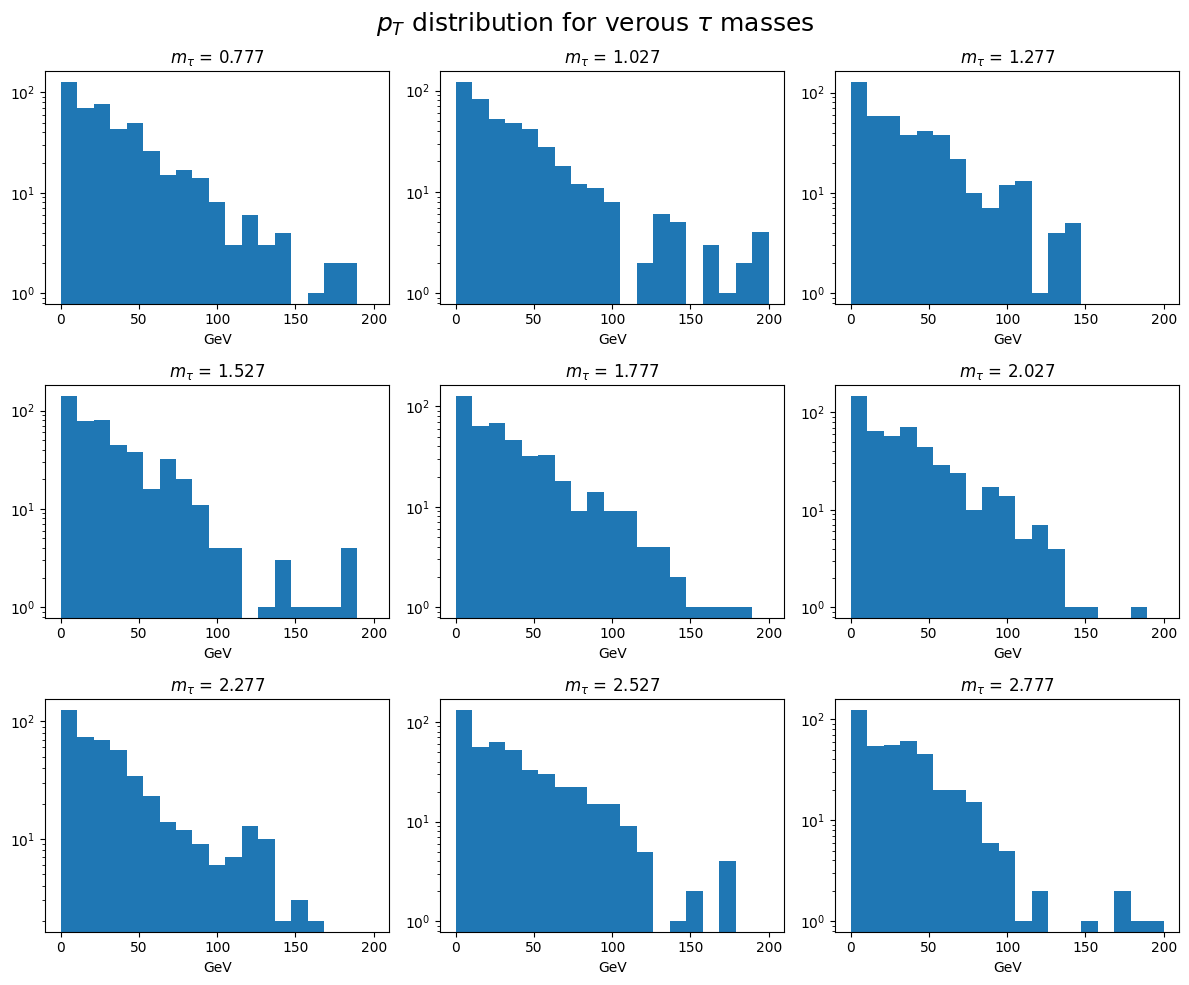

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
BINS = np.linspace(0, 200, 20)

for idx, m_k in enumerate(mass_key):
    ax = axes[idx]
    ax.hist(data[m_k[1]][1]['pT'], bins=BINS)
    ax.set_title(f"$m_\\tau$ = {m_k[0]}")
    ax.set_xlabel('GeV')
    ax.set_yscale('log')

fig.suptitle(f"$p_T$ distribution for verous $\\tau$ masses", fontsize=18)
plt.tight_layout()
plt.show()